In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:

data = {
    'luas_rumah': [50, 60, 70, 80, 90, 100, 110, 120, 130, 140],
    'jumlah_kamar': [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    'jarak_ke_pusat': [10, 9, 8, 7, 6, 5, 4, 3, 2, 1],
    'harga': [300, 350, 400, 450, 500, 600, 700, 800, 900, 1000]
}

df = pd.DataFrame(data)
print(df)

   luas_rumah  jumlah_kamar  jarak_ke_pusat  harga
0          50             2              10    300
1          60             2               9    350
2          70             3               8    400
3          80             3               7    450
4          90             3               6    500
5         100             4               5    600
6         110             4               4    700
7         120             4               3    800
8         130             5               2    900
9         140             5               1   1000


In [ ]:
X = df[['luas_rumah', 'jumlah_kamar', 'jarak_ke_pusat']]
y = df['harga']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# hasil
print("Intercept (a):", round(model.intercept_, 2))
print("Koefisien (b1, b2, b3):", model.coef_)
# b1 (luas_rumah)
# Setiap kenaikan 1 m² luas rumah, maka harga rumah akan naik sebesar b1

# b2 (jumlah_kamar)
# Setiap penambahan 1 kamar, maka harga rumah akan naik sebesar b2

# b3 (jarak_ke_pusat)
# Setiap penambahan 1 km jarak ke pusat kota, maka harga rumah akan berubah (biasanya turun) sebesar b3

Intercept (a): -151.36
Koefisien (b1, b2, b3): [ 7.42574257 12.5        -0.74257426]


In [ ]:
y_pred = model.predict(X_test)

print("Data Testing:")
print(X_test)

print("Harga Asli:", y_test.values)
print("Harga Prediksi:", y_pred)

Data Testing:
   luas_rumah  jumlah_kamar  jarak_ke_pusat
8         130             5               2
1          60             2               9
Harga Asli: [900 350]
Harga Prediksi: [875.  312.5]


In [ ]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 31.25000000000003
MSE: 1015.6250000000035
RMSE: 31.868871959954962


In [ ]:
# contoh: luas_rumah=85, jumlah_kamar=3, jarak_ke_pusat=6
prediksi = model.predict([[85, 3, 6]])
print("Prediksi Harga Rumah:", prediksi[0])

Prediksi Harga Rumah: 512.8712871287129


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


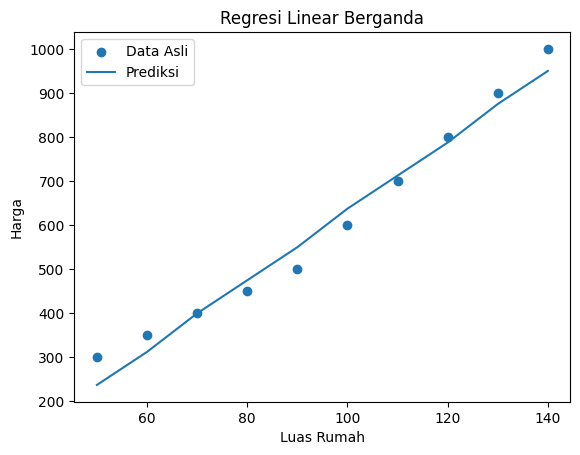

In [ ]:
plt.scatter(df['luas_rumah'], y, label="Data Asli")
plt.plot(df['luas_rumah'], model.predict(X), label="Prediksi")

plt.xlabel("Luas Rumah")
plt.ylabel("Harga")
plt.title("Regresi Linear Berganda")
plt.legend()
plt.show()

Grafik memperlihatkan bahwa harga rumah meningkat seiring bertambahnya luas rumah, menunjukkan hubungan yang konsisten dan searah. Titik-titik data tersebar cukup dekat dengan garis prediksi, sehingga dapat dikatakan model memiliki kemampuan prediksi yang baik. Meskipun terdapat sedikit perbedaan antara nilai asli dan hasil prediksi, hal tersebut masih dalam batas wajar karena pengaruh variabel lain yang tidak terlihat langsung pada grafik. Secara umum, model regresi yang digunakan sudah mampu merepresentasikan pola data dan memberikan hasil prediksi yang cukup akurat.